# RAQIB — Term 4 operations analytics notebook

AI 218 *AI in Operations*. This notebook reproduces the three analytical results behind the dashboard from the same code the API runs (`cloud/raqib_api`): the M/M/c queue model checked against textbook values, the footfall forecast against a seasonal-naive baseline, and the staffing integer program. Data: the labelled simulator (`payload.simulated = true`) plus the exported results in `docs/results/`.

In [1]:
import sys, json, math
sys.path.insert(0, '/Users/krishnamathurm4pro/Desktop/MUSHRIF/cloud')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from raqib_api.ops_theory import mmc, slot_rates, service_level, tills_for_target_rho
from raqib_api.forecast import hourly_counts, fit_predict, seasonal_naive
from raqib_api.workforce import staffing_plan
from raqib_api.simulate import generate
RESULTS = Path('/Users/krishnamathurm4pro/Desktop/MUSHRIF/docs/results')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('modules loaded')

modules loaded


## 1. Queueing theory: M/M/c validation

Erlang-C closed form. Check against the textbook M/M/2 case (λ = 4/h, μ = 3/h): ρ = 0.667, P₀ = 0.2, L_q ≈ 1.067, W_q ≈ 0.267 h. Then sweep the number of tills for the demo store's peak arrival rate.

In [2]:
r = mmc(4, 3, 2)
print(f"rho={r.rho:.3f} P0={r.p0:.3f} Lq={r.lq:.3f} Wq={r.wq*60:.1f} min")
assert abs(r.lq - 1.0667) < 1e-3
k = json.load(open(RESULTS / 'kpis_retail.json'))
w = json.load(open(RESULTS / 'workforce_retail.json'))
lam_peak = max(w['lam']); mu = w['mu']
rows = []
for c in range(1, 7):
    m = mmc(lam_peak, mu, c)
    rows.append({'tills': c, 'rho': round(m.rho, 3), 'Wq_min': None if not m.stable else round(m.wq*60, 2), 'P(wait)': None if not m.stable else round(1 - m.p0 * sum((lam_peak/mu)**n/math.factorial(n) for n in range(c)), 3)})
pd.DataFrame(rows)

rho=0.667 P0=0.200 Lq=1.067 Wq=16.0 min


,tills,rho,Wq_min,P(wait)
0,1,2.740,NaN,NaN
1,2,1.370,NaN,NaN
2,3,0.913,5.11,0.841
3,4,0.685,0.51,0.406
4,5,0.548,0.12,0.177
5,6,0.457,0.03,0.069


At the peak, adding one till when ρ is near 0.9 cuts the expected wait by an order of magnitude; this is the lever the agent's `propose_open_till` pulls, and why the policy requires ρ > 0.85 before it may be proposed.

## 2. Model vs observed

The dashboard's 'Queue model vs observed' card. Observed W_q uses Little's law on the measured queue length. μ is estimated from checkout dwell on video and labelled as such.

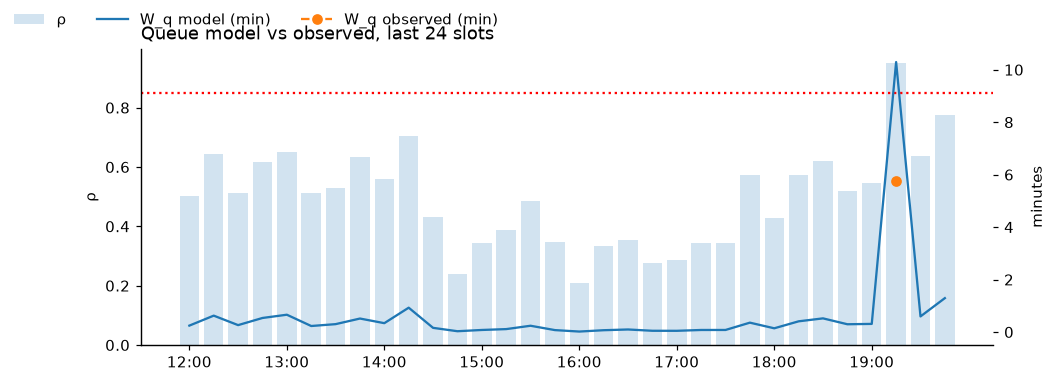

service level (queue <= 3): 0.989  peak rho: 0.951


In [3]:
qm = pd.DataFrame(k['queue_model'])
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(len(qm)), qm['rho'], alpha=0.2, label='ρ')
ax2 = ax.twinx()
ax2.plot(qm['wq_model_min'], label='W_q model (min)')
ax2.plot(qm['wq_observed_min'], 'o--', label='W_q observed (min)')
ax.set_xticks(range(0, len(qm), 4)); ax.set_xticklabels([s[11:16] for s in qm['slot_start']][::4])
ax.axhline(0.85, ls=':', c='r'); ax.set_ylabel('ρ'); ax2.set_ylabel('minutes')
fig.legend(loc='upper left', ncol=3, frameon=False); plt.title('Queue model vs observed, last 24 slots', loc='left'); plt.show()
print('service level (queue <= 3):', k['service_level'], ' peak rho:', k['peak_rho'])

## 3. Forecasting vs seasonal naive

Regenerate 21 days from the labelled simulator (deterministic seed), fit the same GradientBoosting model the API uses, and compare with same-hour-last-week.

sufficient=True MAE=4.341 MAE_naive=4.917 improvement=11.7% MAPE=16.4%


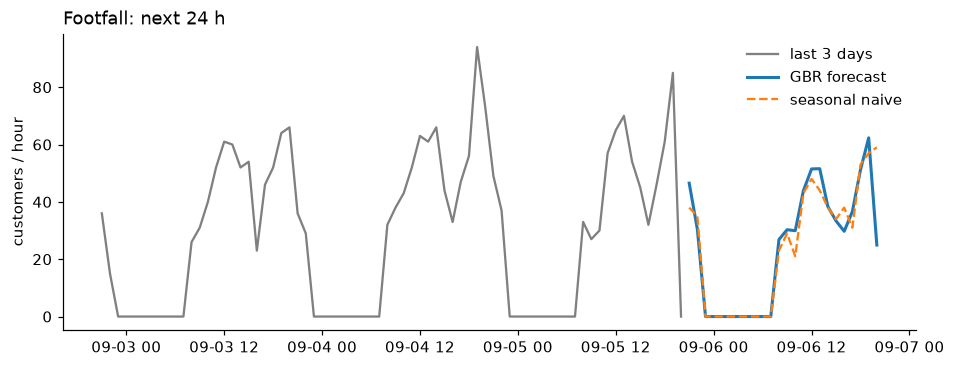

In [4]:
from types import SimpleNamespace
end = datetime.now(timezone.utc).replace(minute=0, second=0, microsecond=0)
rows = generate('raqib_demo_store', 'retail', days=21, seed=7, end=end, tills=3)
events = [SimpleNamespace(ts=datetime.fromisoformat(r['ts']), kind=r['kind'], payload=r['payload']) for r in rows]
series = hourly_counts(events, 'footfall_tick', end=end)
res = fit_predict(series, horizon=24)
print(f"sufficient={res.sufficient} MAE={res.mae} MAE_naive={res.mae_naive} improvement={res.improvement_pct}% MAPE={res.mape}%")
hist = series.iloc[-72:]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(hist.index, hist.values, c='gray', label='last 3 days')
fi = pd.to_datetime([f['ts'] for f in res.forecast])
ax.plot(fi, [f['value'] for f in res.forecast], label='GBR forecast', lw=2)
ax.plot(fi, [f['baseline'] if f['baseline'] is not None else np.nan for f in res.forecast], '--', label='seasonal naive')
ax.legend(frameon=False); ax.set_ylabel('customers / hour'); plt.title('Footfall: next 24 h', loc='left'); plt.show()

The simulator is generated from smooth daily and weekly curves plus Poisson noise, which is close to what seasonal naive assumes, so the margin here is a floor. The pilot target (≥ 20% better) is set for real data with promotions, weather, and school holidays.

## 4. Workforce optimisation (MILP)

Minimise Σ tills subject to ρ ≤ 0.85 per 15-minute slot, integer tills. Toy check first (hand solution [1, 2, 4]), then the demo day.

toy tills [1, 2, 4] staff-hours 7.0
staff-hours 24.25 vs baseline 36.0 (saves 11.75 h); peak tills 4


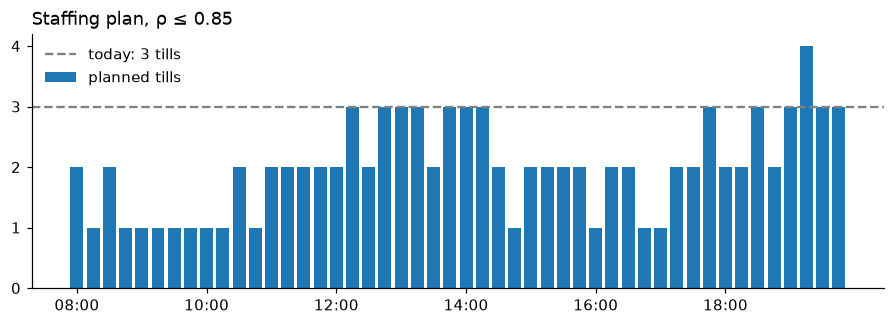

In [5]:
toy = staffing_plan([2, 5, 8], mu=3, max_rho=0.85, max_tills=6, slot_minutes=60)
print('toy tills', toy.tills, 'staff-hours', toy.staff_hours)
assert toy.tills == [1, 2, 4]
plan = staffing_plan(w['lam'], w['mu'], max_rho=0.85, max_tills=max(3, tills_for_target_rho(max(w['lam']), w['mu'])), baseline_tills=3)
print(f"staff-hours {plan.staff_hours} vs baseline {plan.baseline_staff_hours} (saves {plan.savings_hours} h); peak tills {max(plan.tills)}")
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(plan.tills)), plan.tills, label='planned tills')
ax.axhline(3, ls='--', c='gray', label='today: 3 tills')
ax.set_xticks(range(0, len(w['slots']), 8)); ax.set_xticklabels([s[11:16] for s in w['slots']][::8])
ax.legend(frameon=False); plt.title('Staffing plan, ρ ≤ 0.85', loc='left'); plt.show()

## 5. Before / after

Replay the day with the agent's open-till proposals applied (tills = max(3, plan)). Closing tills off-peak is the staff-hour saving above and is not counted as a wait effect.

In [6]:
def total_wait(lams, tills, mu):
    tot = 0.0
    for lam, c in zip(lams, tills):
        m = mmc(lam, mu, c)
        tot += (m.wq * 60 if m.stable else 30) * lam / 4  # customer-minutes per 15-min slot
    return round(tot, 1)
base = total_wait(w['lam'], [3]*len(w['lam']), w['mu'])
after = total_wait(w['lam'], [max(3, c) for c in plan.tills], w['mu'])
print(f"customer-minutes waited: baseline {base}, with proposals {after}, reduction {0 if base == 0 else round((1-after/base)*100,1)}%")

customer-minutes waited: baseline 359.7, with proposals 240.1, reduction 33.2%


## 6. Where the numbers go

`scripts/export_results.py` writes these figures to `docs/results/`; `docs/term4/build_report.py` and `build_deck.py` read them. No number in the report or deck is typed by hand.